Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading...
Test set: (4700, 128, 128, 1)
Running predictions...
Accuracy: 92.32%


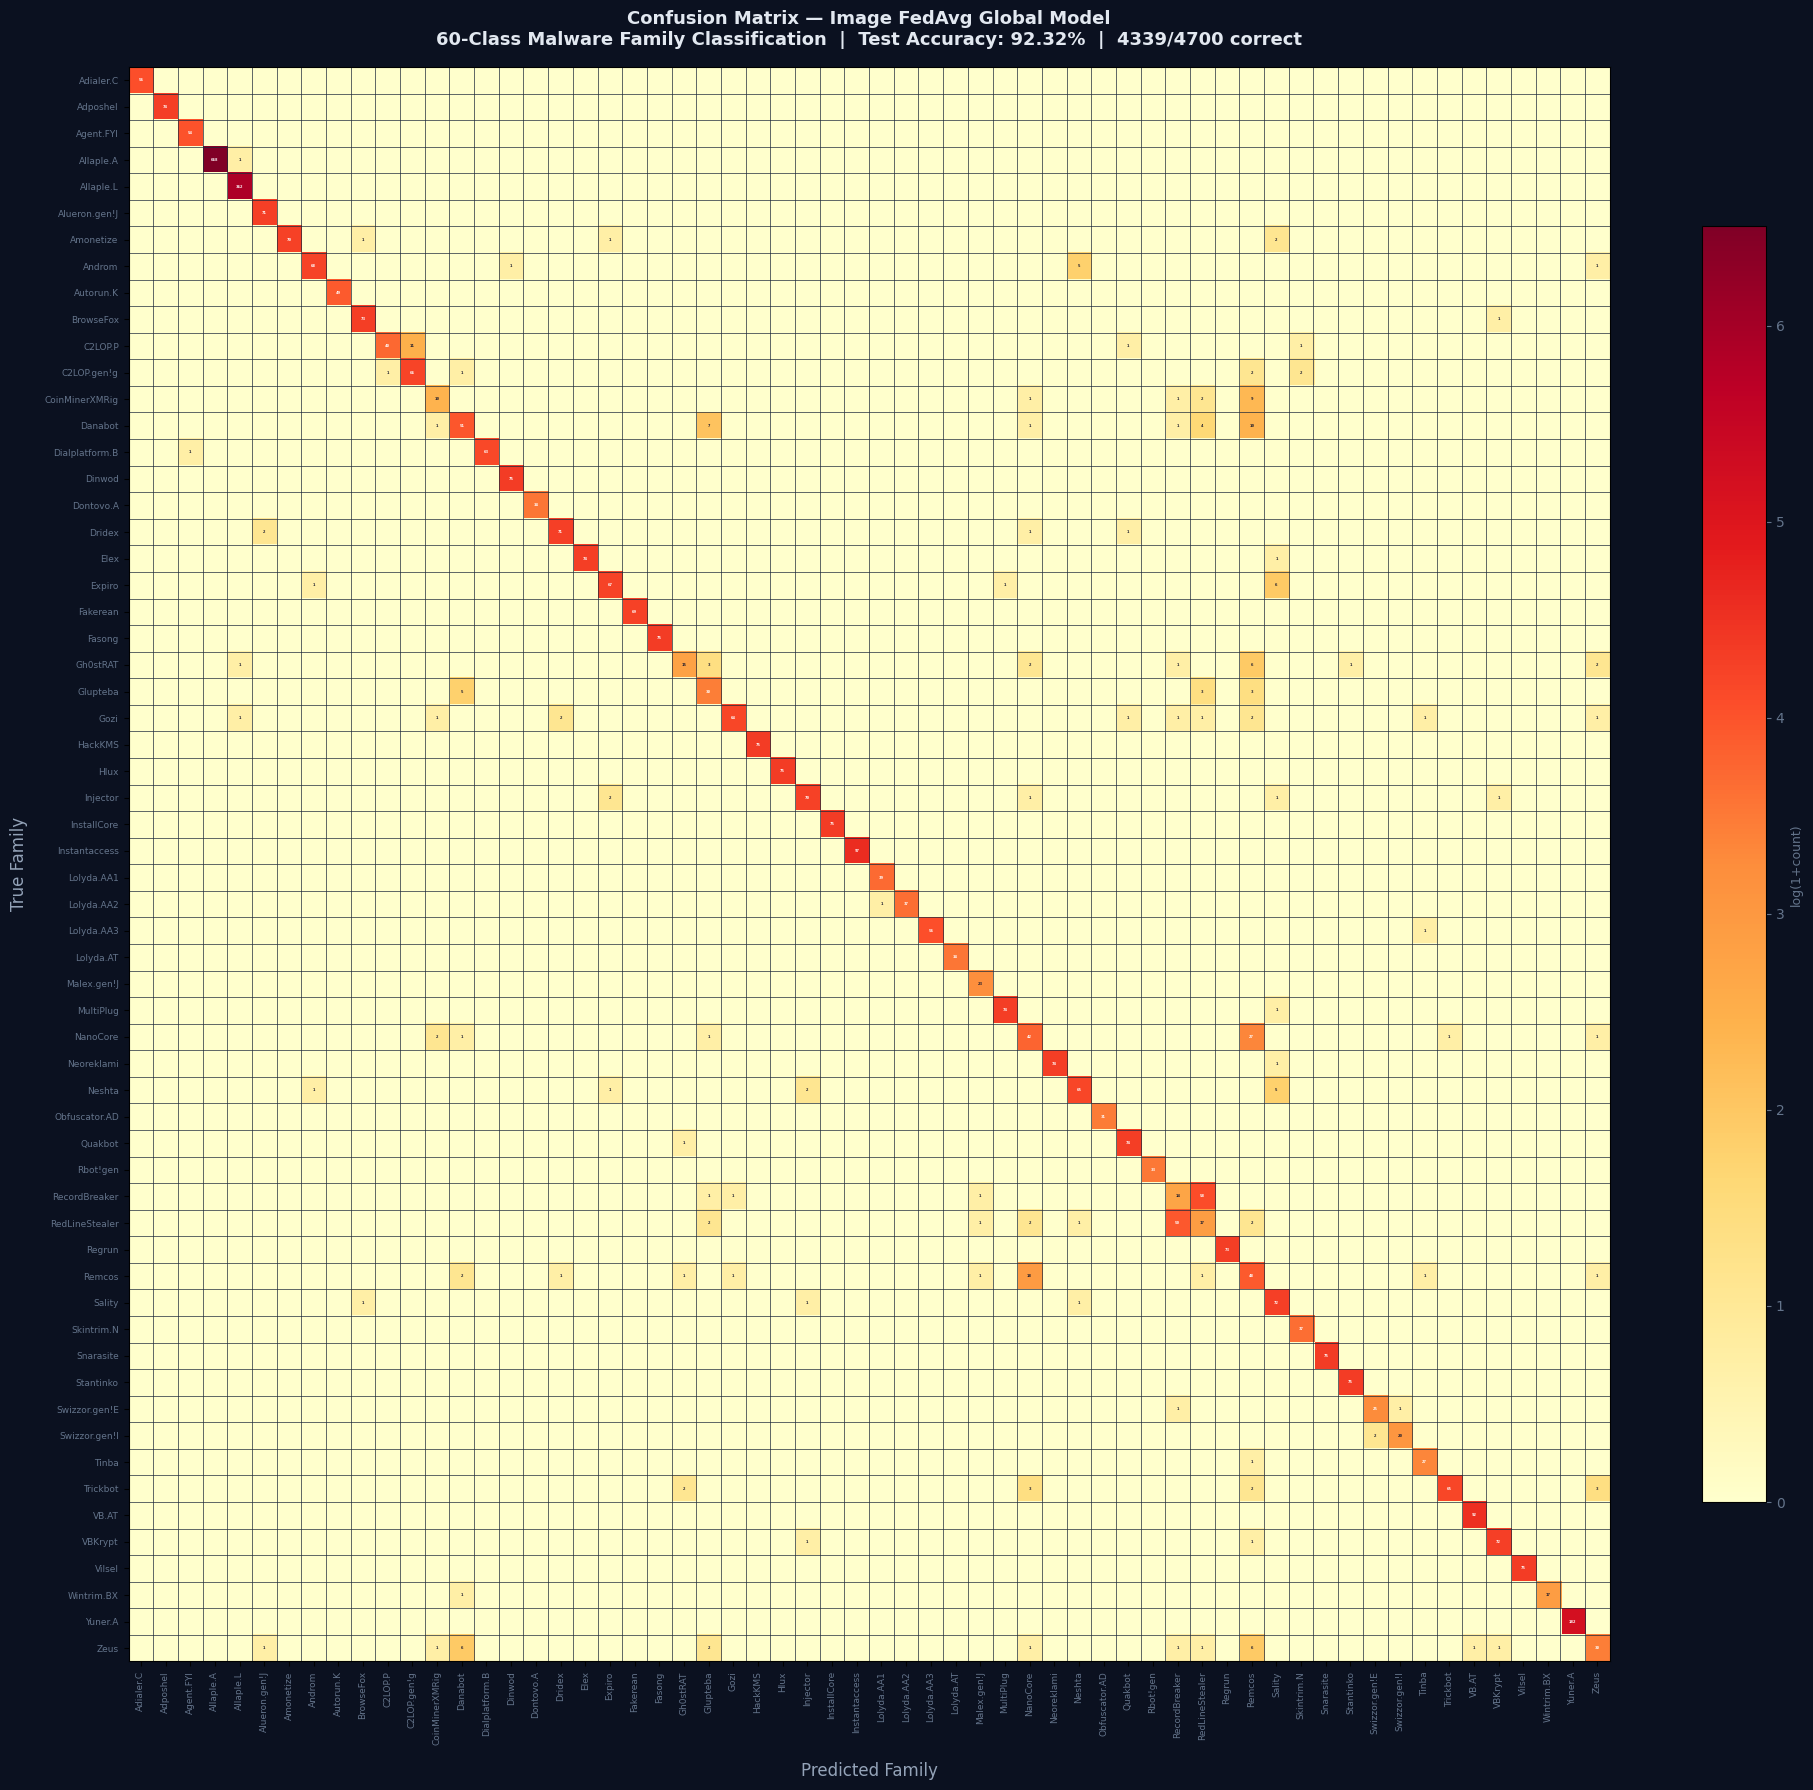

✅ Saved: image_confusion_matrix_full.png


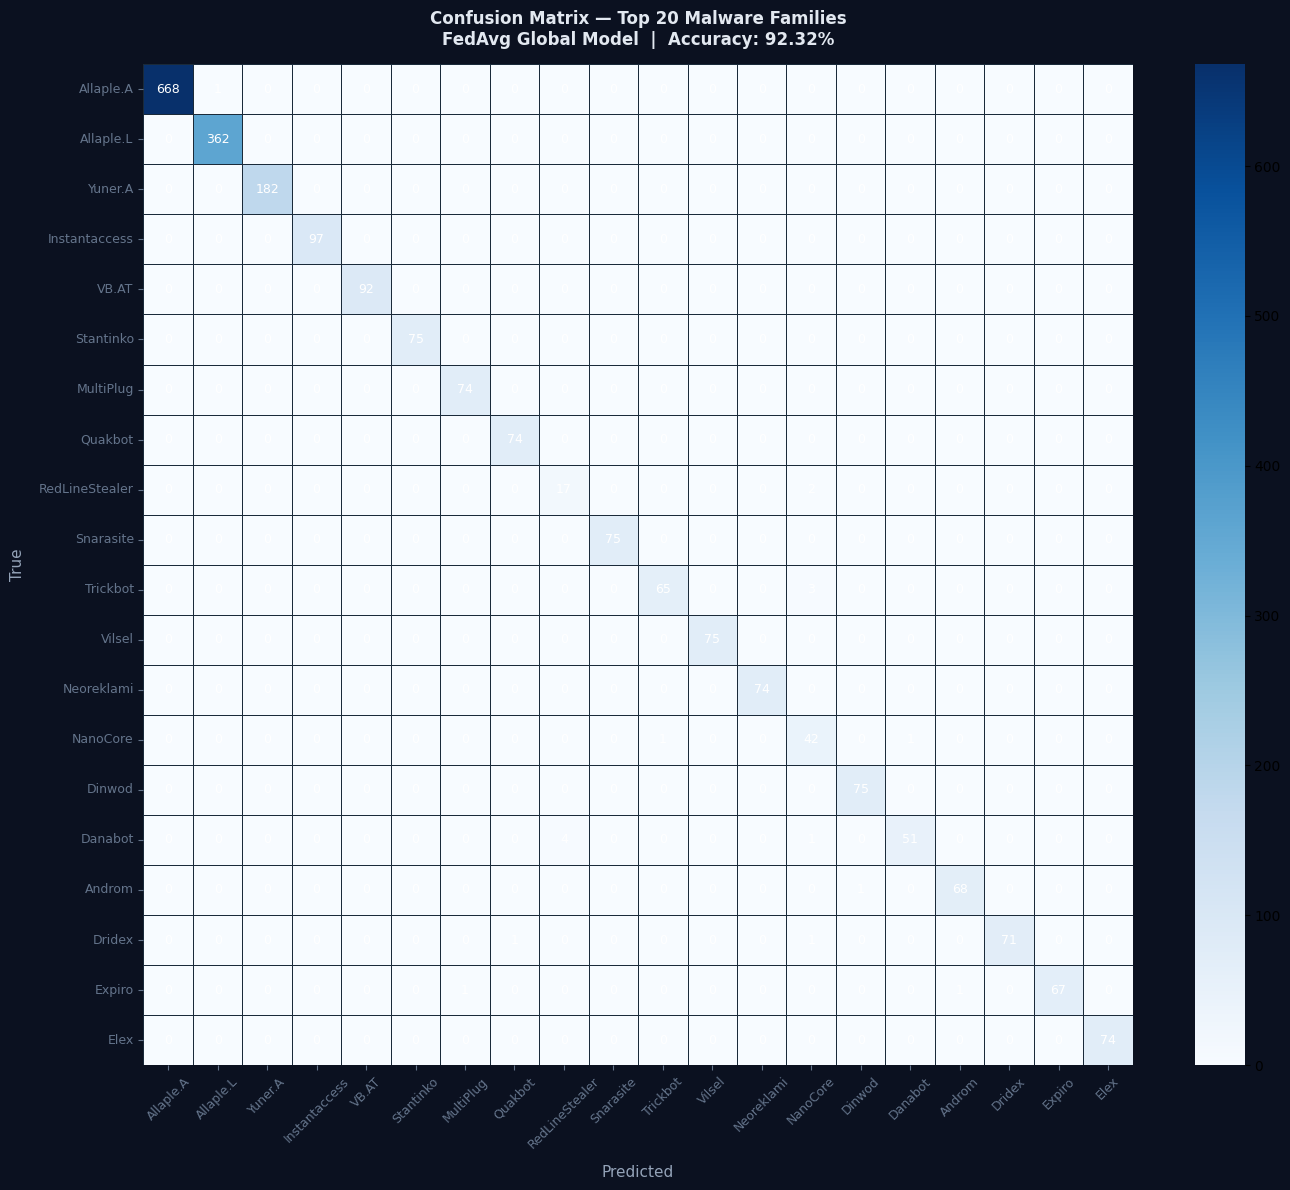

✅ Saved: image_confusion_matrix_top20.png

Per-class accuracy (top 15 families by sample count):
Family                     Samples  Correct   Accuracy
-------------------------------------------------------
Allaple.A                      669      668      99.9%
Allaple.L                      362      362     100.0%
Yuner.A                        182      182     100.0%
Instantaccess                   97       97     100.0%
VB.AT                           92       92     100.0%
Stantinko                       75       75     100.0%
MultiPlug                       75       74      98.7%
Quakbot                         75       74      98.7%
RedLineStealer                  75       17      22.7%
Snarasite                       75       75     100.0%
Trickbot                        75       65      86.7%
Vilsel                          75       75     100.0%
Neoreklami                      75       74      98.7%
NanoCore                        75       42      56.0%
Dinwod                

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pickle, json
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

tf.get_logger().setLevel('ERROR')

PATHS = {
    'model'  : '/content/drive/MyDrive/FYP_Federated/image_federated_global.h5',
    'X_test' : '/content/drive/MyDrive/FYP_Processed_Data/X_test.npy',
    'y_test' : '/content/drive/MyDrive/FYP_Processed_Data/y_test.npy',
    'le'     : '/content/drive/MyDrive/FYP_Models/label_encoder.pkl',
    'output' : '/content/drive/MyDrive/FYP_Federated',
}

print('Loading...')
X_test = np.load(PATHS['X_test'])
y_test = np.load(PATHS['y_test'])
with open(PATHS['le'],'rb') as f: le = pickle.load(f)
class_names = le.classes_.tolist()
y_true = np.argmax(y_test, axis=1)

model = tf.keras.models.load_model(PATHS['model'], compile=False)
print(f'Test set: {X_test.shape}')

# Predict in batches
print('Running predictions...')
preds = []
for i in range(0, len(X_test), 100):
    preds.append(model(X_test[i:i+100].astype(np.float32), training=False).numpy())
preds  = np.vstack(preds)
y_pred = np.argmax(preds, axis=1)
acc    = np.mean(y_pred == y_true)
print(f'Accuracy: {acc*100:.2f}%')

# ── Full 60x60 confusion matrix ───────────────────────
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

fig, ax = plt.subplots(figsize=(20, 18))
fig.patch.set_facecolor('#0B1120')
ax.set_facecolor('#0B1120')

# Normalize for color, show raw counts as text
cm_norm = cm.astype(float)
cm_norm[cm_norm > 0] = np.log1p(cm_norm[cm_norm > 0]) # Use log1p for better visual distribution

im = ax.imshow(cm_norm, cmap='YlOrRd', aspect='auto') # High-contrast colormap

# Adaptive text — white on dark, black on light
thresh = cm_norm.max() / 2.0
for i in range(len(class_names)):
    for j in range(len(class_names)):
        val = cm[i, j]
        if val > 0:
            color = 'white' if cm_norm[i, j] > thresh else '#1a1a2e'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=3, fontweight='bold', color=color, # Smaller font for 60x60
                    fontfamily='monospace')

ax.set_xlabel('Predicted Family', fontsize=12,
              color='#94A3B8', labelpad=12)
ax.set_ylabel('True Family', fontsize=12,
              color='#94A3B8', labelpad=12)
ax.set_title(f'Confusion Matrix — Image FedAvg Global Model\n'
             f'60-Class Malware Family Classification  |  '
             f'Test Accuracy: {acc*100:.2f}%  |  '
             f'{int(np.sum(y_pred==y_true))}/{len(y_true)} correct',
             fontsize=13, color='#E2E8F0', fontweight='bold', pad=16)

ax.set_xticks(range(len(class_names)))
ax.set_xticklabels([name[:15] for name in class_names], rotation=90, fontsize=6.5, color='#64748B') # Smaller labels
ax.set_yticks(range(len(class_names)))
ax.set_yticklabels([name[:15] for name in class_names], fontsize=6.5, color='#64748B', rotation=0)

# Grid lines between cells
ax.set_xticks(np.arange(-.5, len(class_names), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(class_names), 1), minor=True)
ax.grid(which='minor', color='#1E293B', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(colors='#64748B')
cbar.set_label('log(1+count)', color='#64748B', fontsize=9)

plt.tight_layout()
path1 = f"{PATHS['output']}/image_confusion_matrix_full.png"
plt.savefig(path1, dpi=130, bbox_inches='tight', facecolor='#0B1120')
plt.show()
print(f'✅ Saved: image_confusion_matrix_full.png')

# ── Top 20 families — annotated ───────────────────────
top20     = np.argsort(cm.sum(axis=1))[::-1][:20]
cm20      = cm[np.ix_(top20, top20)]
labels20  = [class_names[i][:15] for i in top20]

fig2, ax2 = plt.subplots(figsize=(14, 12))
fig2.patch.set_facecolor('#0B1120')
ax2.set_facecolor('#0B1120')

sns.heatmap(cm20, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=labels20,
            yticklabels=labels20,
            linewidths=0.5,
            linecolor='#1a2a3a',
            annot_kws={'size':9, 'color':'white'},
            ax=ax2)

ax2.set_xlabel('Predicted', fontsize=11, color='#94A3B8', labelpad=10)
ax2.set_ylabel('True',      fontsize=11, color='#94A3B8', labelpad=10)
ax2.set_title(f'Confusion Matrix — Top 20 Malware Families\n'
              f'FedAvg Global Model  |  Accuracy: {acc*100:.2f}%',
              fontsize=12, color='#E2E8F0', fontweight='bold', pad=14)

ax2.tick_params(axis='x', colors='#64748B', labelsize=9, rotation=45)
ax2.tick_params(axis='y', colors='#64748B', labelsize=9, rotation=0)

plt.tight_layout()
path2 = f"{PATHS['output']}/image_confusion_matrix_top20.png"
plt.savefig(path2, dpi=130, bbox_inches='tight', facecolor='#0B1120')
plt.show()
print(f'✅ Saved: image_confusion_matrix_top20.png')

# ── Per-class accuracy summary ────────────────────────
print('\nPer-class accuracy (top 15 families by sample count):')
print(f'{"Family":<25} {"Samples":>8} {"Correct":>8} {"Accuracy":>10}')
print('-'*55)
for ci in np.argsort(cm.sum(axis=1))[::-1][:15]:
    total_ci   = cm[ci].sum()
    correct_ci = cm[ci, ci]
    print(f'{class_names[ci]:<25} {total_ci:>8} {correct_ci:>8} {correct_ci/total_ci*100:>9.1f}%')

print(f'\n{"="*55}')
print(f'Overall Accuracy: {acc*100:.2f}%')
print(f'Correct: {int(np.sum(y_pred==y_true))} / {len(y_true)}')
print(f'{"="*55}')
print('\nSaved:')
print(f'  image_confusion_matrix_full.png')
print(f'  image_confusion_matrix_top20.png')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


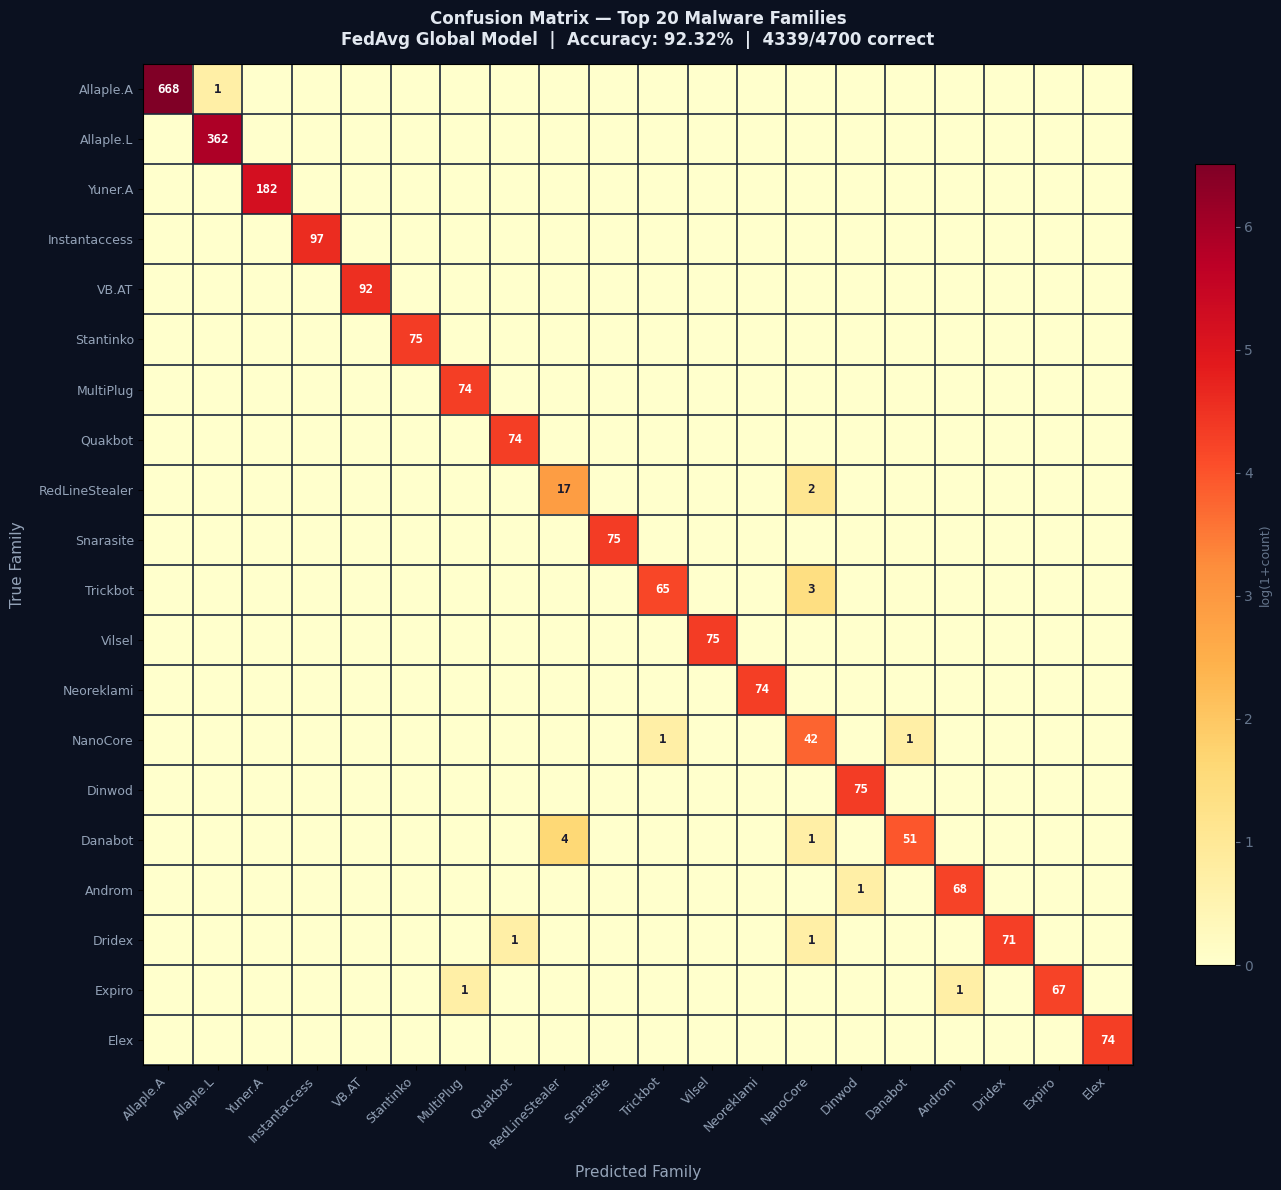

✅ Saved: image_confusion_matrix_top20.png


In [2]:
# Better confusion matrix — high contrast, visible text
import numpy as np, matplotlib.pyplot as plt, matplotlib
import pickle, tensorflow as tf, seaborn as sns
from sklearn.metrics import confusion_matrix

tf.get_logger().setLevel('ERROR')
from google.colab import drive
drive.mount('/content/drive')

PATHS = {
    'model'  : '/content/drive/MyDrive/FYP_Federated/image_federated_global.h5',
    'X_test' : '/content/drive/MyDrive/FYP_Processed_Data/X_test.npy',
    'y_test' : '/content/drive/MyDrive/FYP_Processed_Data/y_test.npy',
    'le'     : '/content/drive/MyDrive/FYP_Models/label_encoder.pkl',
    'output' : '/content/drive/MyDrive/FYP_Federated',
}
X_test  = np.load(PATHS['X_test'])
y_test  = np.load(PATHS['y_test'])
with open(PATHS['le'],'rb') as f: le=pickle.load(f)
class_names = le.classes_.tolist()
y_true = np.argmax(y_test, axis=1)
model  = tf.keras.models.load_model(PATHS['model'], compile=False)

preds = []
for i in range(0,len(X_test),100):
    preds.append(model(X_test[i:i+100].astype(np.float32),training=False).numpy())
preds  = np.vstack(preds)
y_pred = np.argmax(preds, axis=1)
acc    = np.mean(y_pred==y_true)
cm     = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

# ── TOP 20 — High contrast ────────────────────────────
top20  = np.argsort(cm.sum(axis=1))[::-1][:20]
cm20   = cm[np.ix_(top20, top20)]
lab20  = [class_names[i][:16] for i in top20]

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0B1120')
ax.set_facecolor('#0B1120')

# Normalize for color, show raw counts as text
cm20_norm = cm20.astype(float)
cm20_norm[cm20_norm>0] = np.log1p(cm20_norm[cm20_norm>0])

im = ax.imshow(cm20_norm, cmap='YlOrRd', aspect='auto')

# Adaptive text — white on dark, black on light
thresh = cm20_norm.max() / 2.0
for i in range(len(lab20)):
    for j in range(len(lab20)):
        val = cm20[i,j]
        if val > 0:
            color = 'white' if cm20_norm[i,j] > thresh else '#1a1a2e'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color,
                    fontfamily='monospace')

ax.set_xticks(range(len(lab20))); ax.set_xticklabels(lab20, rotation=45, ha='right',
    fontsize=9, color='#94A3B8')
ax.set_yticks(range(len(lab20))); ax.set_yticklabels(lab20, fontsize=9, color='#94A3B8')
ax.set_xlabel('Predicted Family', fontsize=11, color='#94A3B8', labelpad=10)
ax.set_ylabel('True Family',      fontsize=11, color='#94A3B8', labelpad=10)
ax.set_title(f'Confusion Matrix — Top 20 Malware Families\n'
             f'FedAvg Global Model  |  Accuracy: {acc*100:.2f}%  |  '
             f'{int(np.sum(y_pred==y_true))}/{len(y_true)} correct',
             fontsize=12, color='#E2E8F0', fontweight='bold', pad=14)

# Grid lines between cells
ax.set_xticks(np.arange(-.5, len(lab20), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(lab20), 1), minor=True)
ax.grid(which='minor', color='#1E293B', linewidth=1.2)
ax.tick_params(which='minor', bottom=False, left=False)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(colors='#64748B')
cbar.set_label('log(1+count)', color='#64748B', fontsize=9)

plt.tight_layout()
path = f"{PATHS['output']}/image_confusion_matrix_top20.png"
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='#0B1120')
plt.show()
print(f'✅ Saved: image_confusion_matrix_top20.png')